In [15]:
from google.colab import files

uploaded = files.upload()

Saving DPCSLabCore.py to DPCSLabCore (2).py


In [16]:
# ЛР №1. Кластер №23, міжкластерна топологія — кільцева

import math
import os
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import DPCSLabCore as core


In [17]:
# 1. Функція побудови масштабованої топології

def build(cluster: nx.Graph, rank: int) -> nx.Graph:
    if rank <= 0:
        return nx.Graph()
    if rank == 1:
        return cluster.copy()

    G = core.replicate(cluster, n=rank)

    # ========================================================
    # РЕГУЛЯРНІ ЗВ'ЯЗКИ
    # Кожен кластер з'єднується з наступним.
    # Останній кластер з'єднується з першим -> кільце.
    # ========================================================
    regular_pairs = [
        (1, 1),
        (3, 3),
        (6, 6),
        (8, 8),
    ]

    for p in range(rank):
        next_p = (p + 1) % rank
        # Для неорієнтованого графа при rank=2 достатньо одного напрямку.
        if rank == 2 and p == 1:
            continue

        for v1, v2 in regular_pairs:
            G.add_edge((p, v1), (next_p, v2))

    # НЕРЕГУЛЯРНІ ЗВ'ЯЗКИ
    irregular_rules = [
        # сині пунктирні: 7 -> 7 через 2 кластери
        (7, 7, 2),

        # зелені пунктирні: 4 -> 5 через 2 кластери
        (4, 5, 2),

        # жовті пунктирні: 2 -> 2 через 3 кластери
        (2, 2, 3),

        # бірюзові пунктирні: 5 -> 4 через 3 кластери
        (5, 4, 3),
    ]

    for v1, v2, step in irregular_rules:
        if rank <= step:
            continue

        for p in range(rank):
            next_p = (p + step) % rank
            if p != next_p:
                G.add_edge((p, v1), (next_p, v2))

    return G


In [18]:
# 2. Базовий кластер №23
# Точна структура з наданого рисунка: 8 вершин, 10 внутрішніх ребер.

cluster = nx.Graph()
cluster.add_nodes_from(range(1, 9))
cluster.add_edges_from([
    (1, 2),
    (2, 3),
    (1, 4),
    (4, 6),
    (3, 5),
    (5, 8),
    (2, 4),
    (2, 5),
    (4, 7),
    (7, 5),
])

print('Кластер №23')
print('Вершин:', cluster.number_of_nodes())
print('Внутрішніх ребер:', cluster.number_of_edges())
print('Ребра:', sorted(cluster.edges()))


Кластер №23
Вершин: 8
Внутрішніх ребер: 10
Ребра: [(1, 2), (1, 4), (2, 3), (2, 4), (2, 5), (3, 5), (4, 6), (4, 7), (5, 7), (5, 8)]


In [19]:
# 3. Розрахунок характеристик для вибраних кроків масштабування

def build_table(cluster: nx.Graph, ranks: list[int]) -> pd.DataFrame:
    rows = []

    for rank in ranks:
        G = build(cluster, rank)
        ch = core.characteristics(G)
        rows.append({
            'Крок': rank,
            'N': ch['N'],
            'E': ch['E'],
            'Ступінь': ch['Ступінь'],
            'Діаметр': ch['Діаметр'],
            'Середній діаметр': ch['Середній діаметр'],
            'Топологічний трафік': ch['Топологічний трафік'],
            'Вартість': ch['Вартість'],
        })

    return pd.DataFrame(rows).set_index('Крок')

ranks = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 30, 40, 60, 80, 100, 125]
results = build_table(cluster, ranks)

print(results.to_string(float_format=lambda x: f'{x:.3f}'))
results.to_csv('LR1_cluster23_results.csv')


         N     E  Ступінь  Діаметр  Середній діаметр  Топологічний трафік  Вартість
Крок                                                                               
1        8    10        4        4             1.857                1.486       128
2       16    24        4        5             2.483                1.656       320
3       24    48        5        4             2.315                1.158       480
4       32    70        6        4             2.383                1.089       768
5       40    85        6        5             2.615                1.231      1200
6       48   105        6        5             2.702                1.235      1440
8       64   144        6        5             2.881                1.280      1920
10      80   180        6        5             3.108                1.381      2400
15     120   270        6        6             3.559                1.582      4320
20     160   360        6        7             4.006                1.780   

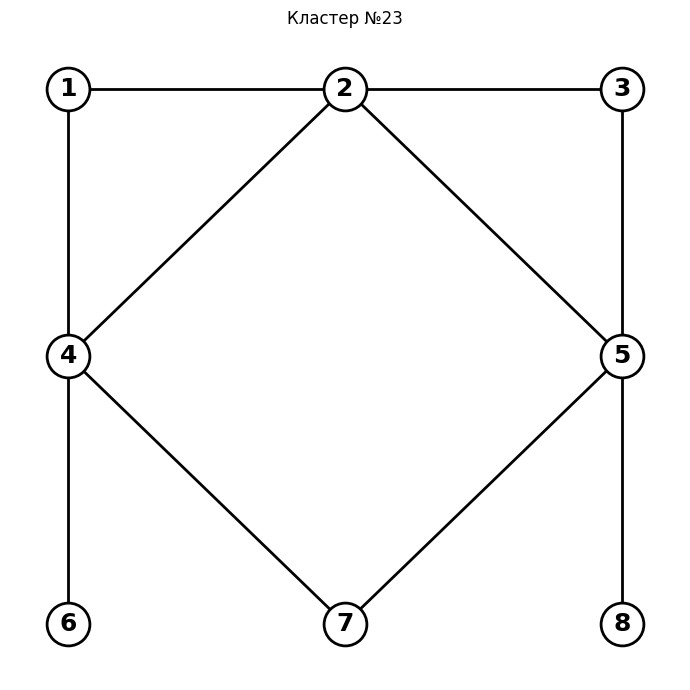

In [20]:
# 4. Візуалізація кластера №23 у тому самому розташуванні,
# як на виданому рисунку.

cluster_pos = {
    1: (-2, 2),
    2: (0, 2),
    3: (2, 2),
    4: (-2, 0),
    5: (2, 0),
    6: (-2, -2),
    7: (0, -2),
    8: (2, -2),
}

plt.figure(figsize=(7, 7))
nx.draw_networkx_edges(cluster, cluster_pos, edge_color='black', width=2)
nx.draw_networkx_nodes(
    cluster, cluster_pos,
    node_size=950,
    node_color='white',
    edgecolors='black',
    linewidths=2,
)
nx.draw_networkx_labels(cluster, cluster_pos, font_size=18, font_weight='bold')
plt.title('Кластер №23')
plt.axis('off')
plt.tight_layout()
plt.show()


/tmp/ipykernel_11731/3966160807.py:43: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/tmp/ipykernel_11731/3966160807.py:66: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


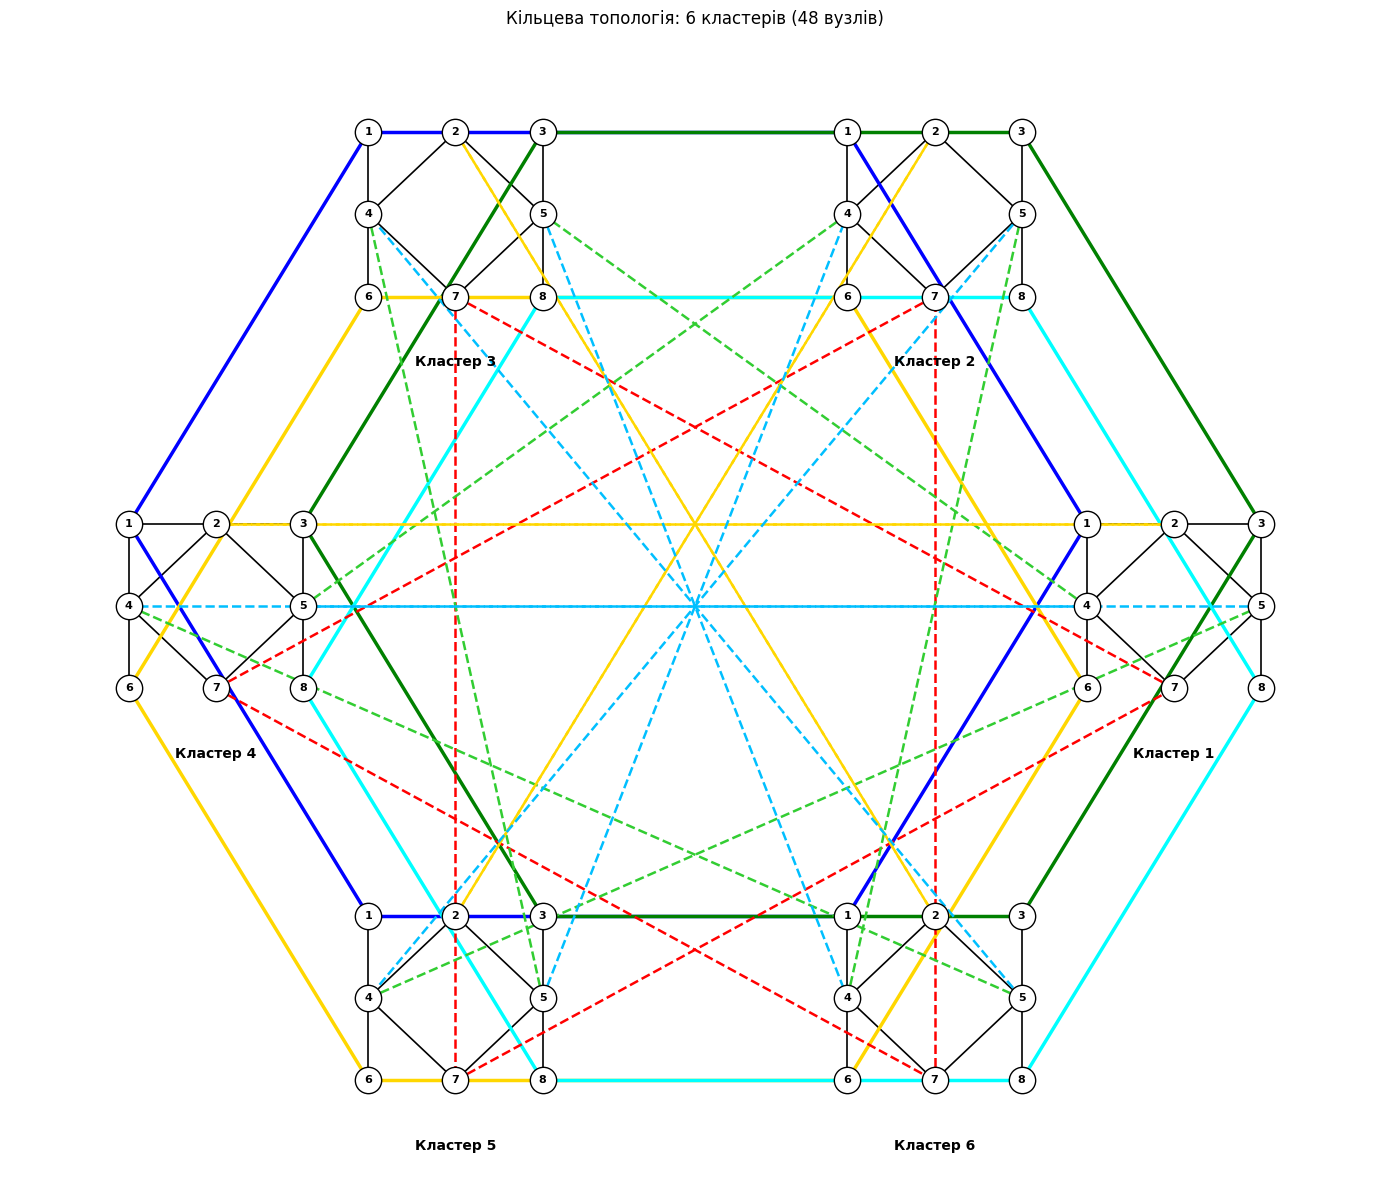


Характеристики:
N: 48
E: 105
Ступінь: 6
Діаметр: 5
Середній діаметр: 2.702
Топологічний трафік: 1.235
Вартість: 1440


In [33]:
# 5. Візуалізація 6 кластерів (48 вузлів)
# Суцільні кольорові — регулярні, пунктирні — нерегулярні.

def visualize_graph(num_clusters=6):
    G = build(cluster, num_clusters)
    radius = 11
    pos = {}

    for c in range(num_clusters):
        angle = 2 * math.pi * c / num_clusters
        cx = radius * math.cos(angle)
        cy = radius * math.sin(angle)
        for v, (dx, dy) in cluster_pos.items():
            pos[(c, v)] = (cx + dx, cy + dy)

    plt.figure(figsize=(14, 12))

    # Внутрішні ребра кластера.
    internal_edges = []
    for c in range(num_clusters):
        internal_edges.extend([((c, u), (c, v)) for u, v in cluster.edges()])

    nx.draw_networkx_edges(
        G, pos,
        edgelist=internal_edges,
        edge_color='black',
        width=1.2,
    )

    # Регулярні зв'язки.
    regular = [
        ('blue', 1, 1),
        ('green', 3, 3),
        ('gold', 6, 6),
        ('cyan', 8, 8),
    ]

    for color, v1, v2 in regular:
        edges = [
            ((c, v1), ((c + 1) % num_clusters, v2))
            for c in range(num_clusters)
        ]
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges,
            edge_color=color,
            width=2.5,
            connectionstyle='arc3,rad=0.10',
        )

    # Нерегулярні зв'язки.
    irregular = [
        ('red', 7, 7, 2),
        ('limegreen', 4, 5, 2),
        ('gold', 2, 2, 3),
        ('deepskyblue', 5, 4, 3),
    ]

    for color, v1, v2, step in irregular:
        if num_clusters <= step:
            continue
        edges = [
            ((c, v1), ((c + step) % num_clusters, v2))
            for c in range(num_clusters)
        ]
        nx.draw_networkx_edges(
            G, pos,
            edgelist=edges,
            edge_color=color,
            style='dashed',
            width=1.8,
            connectionstyle='arc3,rad=0.15',
        )

    nx.draw_networkx_nodes(
        G, pos,
        node_size=360,
        node_color='white',
        edgecolors='black',
    )
    labels = {(c, v): str(v) for c in range(num_clusters) for v in range(1, 9)}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold')

    for c in range(num_clusters):
        angle = 2 * math.pi * c / num_clusters
        cx = radius * math.cos(angle)
        cy = radius * math.sin(angle)
        plt.text(cx, cy - 3.7, f'Кластер {c + 1}', ha='center', fontsize=10, fontweight='bold')

    plt.title(f'Кільцева топологія: {num_clusters} кластерів ({8 * num_clusters} вузлів)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    ch = core.characteristics(G)
    print('\nХарактеристики:')
    for key in ['N', 'E', 'Ступінь', 'Діаметр', 'Середній діаметр', 'Топологічний трафік', 'Вартість']:
        value = ch[key]
        print(f'{key}: {value:.3f}' if isinstance(value, float) else f'{key}: {value}')

visualize_graph(6)
